In [1]:
#TOPIC Importing libraries
import pandas as pd
import json
import ast
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt


In [2]:
with open(r'../../export/export.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

In [3]:
usuarios = pd.DataFrame.from_dict(data["usuarios"], orient = 'index').reset_index()
usuarios = usuarios.rename(columns={'index': 'user_id'})

In [4]:
# Excluir linhas com valores de createAt nulos
usuarios = usuarios.dropna(subset=['createdAt'])

In [5]:
# Excluir linhas em que o campo questions está vazio ([])
usuarios = usuarios[usuarios['questions'].apply(str) != "[]"]


In [6]:
# 1. Converte datas tratando as variações de formato ISO
usuarios['preenchimento_dt'] = pd.to_datetime(usuarios['createdAt'], format='ISO8601', errors='coerce')


In [7]:
# 2. Transforma para o formato YYYY-MM-DD (como string ou objeto date)
usuarios['preenchimento_dt'] = usuarios['preenchimento_dt'].dt.strftime('%Y-%m-%d')

In [8]:
# 3. Alterar tipo de coluna para datetime64[ns] para coluna: 'preenchimento_dt'
usuarios = usuarios.astype({'preenchimento_dt': 'datetime64[ns]'})

In [9]:
usuarios = usuarios[usuarios['preenchimento_dt'] >= datetime.strptime('2025-07-01T01:26:36.610Z', '%Y-%m-%dT%H:%M:%S.%fZ')]

In [10]:
# Reseta o index antes do explode para manter o vínculo
df_aux = usuarios[['user_id', 'questions', 'nomeCalculadora', 'preenchimento_dt']].explode('questions')

# Normaliza os dados
df_pergunta_resp = pd.json_normalize(df_aux['questions'])

# Combina de volta com o ID
df_pergunta_resp['user_id'] = df_aux['user_id'].values
# Adiciona a coluna nomeCalculadora
df_pergunta_resp['nomeCalculadora'] = df_aux['nomeCalculadora'].values
df_pergunta_resp['preenchimento_dt'] = df_aux['preenchimento_dt'].values
df_pergunta_resp['Answer'] = df_pergunta_resp['selectedOption'].combine_first(df_pergunta_resp['selectedValue'])

resultado = df_pergunta_resp[['user_id', 'nomeCalculadora', 'preenchimento_dt', 'question', 'Answer']]


In [11]:
#excluir linhas com os seguintes textos na coluna 'question' : 'Fatores de risco pré-existentes' , 'Fatores de risco obstétricos', 'Fatores de risco transitórios'
resultado = resultado[~resultado['question'].isin(['Fatores de risco pré-existentes', 'Fatores de risco obstétricos', 'Fatores de risco transitórios'])]

In [12]:
resultado['question'] = resultado['question'].str.strip()

In [13]:
print(repr(resultado.iloc[261]['question']))

'A paciente é fumante'


In [14]:
resultado['question'] = resultado['question'].str.replace(r'\n|\r', ' ', regex=True)
resultado['question'] = resultado['question'].str.replace(r'\s+', ' ', regex=True)

In [15]:
# 1. Definimos a lista de perguntas que caracteriza a calculadora caprini
perguntas_caprini = [
    'Idade (Anos)',
    'Sexo',
    'Tipo de cirurgia',
    'Evento recente (< 1 mês)', 
    'Doença venosa ou distúrbio de coagulação',
    'Mobilidade',
    'Outras histórias presentes e passadas'
]

# 2. Criamos uma função para verificar se o grupo atende aos critérios
def identificar_caprini(group):
    # Verificamos se TODAS as perguntas da lista estão presentes neste grupo
    contem_perguntas = all(p in group['question'].values for p in perguntas_caprini)
    
    # Se contém as perguntas e o nome da calculadora está nulo/vazio
    if contem_perguntas:
        # Preenchemos os valores nulos especificamente desse grupo com 'Caprini'
        group['nomeCalculadora'] = group['nomeCalculadora'].fillna('Caprini').replace('', 'Caprini')
    
    return group

# 3. Aplicamos a lógica agrupando por usuário e data
resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_caprini)

/tmp/ipykernel_16147/1151977498.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_caprini)


In [16]:
# 1. Definimos a lista de perguntas que caracteriza a calculadora RCOG
perguntas_rcog = [
    'Condição atual da paciente',
    'Altura',
    'Peso',
    'TEV anterior (exceto um único evento relacionado a uma cirurgia de grande porte)',
    'Anteriormente teve TEV provocado por uma cirurgia de grande porte',
    'Obesidade (Calculado)',
    'Tem alto risco de trombofilia conhecida devido à deficiência de antitrombina ou proteína C ou S, composta ou homozigótica para trombofilia de baixo risco',
    'Tem outras comorbidades médicas (por exemplo, câncer, insuficiência cardíaca, lúpus eritematoso sistêmico ativo, etc.)',
    'A paciente tem mais de 35 anos',
    'Tem história familiar de tromboembolismo venoso não provocado ou relacionado ao estrogênio em um parente de primeiro grau',
    'Tem baixo risco de trombofilia conhecida - sem tromboembolismo venoso: heterozigoto para mutações do fator V de Leiden ou G20210A protrombina',
    'Paraplegia',
    'A paciente já deu à luz três vezes ou mais',
    'A paciente é fumante',
    'A paciente tem varizes macroscópicas',
    'A tecnologia de reprodução assistida (ART) ou fertilização in vitro (FIV) foi usada para alcançar a gravidez',
    'Paciente teve cesariana em trabalho de parto',
    'Paciente tem pré-eclâmpsia na gestação atual',
    'A paciente tem gestações múltiplas ou gêmeos, trigêmeos, etc.',
    'A cesariana foi eletiva ou conhecida pela paciente antes do parto',
    'Foi submetida a parto operatório de cavidade média ou rotacional',
    'Experimentou trabalho de parto prolongado de mais de 24 horas',
    'A paciente apresentou hemorragia pós-parto (HPP) superior a 1 litro e necessitou de transfusão',
    'A paciente teve um parto prematuro de menos de 37 semanas na gravidez atual',
    'Natimorto ocorreu na gravidez atual',
    'A paciente está no primeiro trimestre e foi diagnosticada com síndrome de hiperestimulação ovariana (OHSS)',
    'Experimenta hiperêmese',
    'A paciente foi submetida a algum procedimento cirúrgico na gravidez ou no puerpério, exceto ao reparo imediato do períneo (por exemplo, apendicectomia ou esterilização pós-parto).',
    'Atualmente tem uma infecção sistêmica',
    'Imobilidade *Paciente acamada ou com mobilidade reduzida.'
]

# 2. Criamos uma função para verificar se o grupo atende aos critérios
def identificar_rcog(group):
    # Verificamos se TODAS as perguntas da lista estão presentes neste grupo
    contem_perguntas = all(p in group['question'].values for p in perguntas_rcog)
    
    # Se contém as perguntas e o nome da calculadora está nulo/vazio
    if contem_perguntas:
        # Preenchemos os valores nulos especificamente desse grupo com 'RCOG'
        group['nomeCalculadora'] = group['nomeCalculadora'].fillna('RCOG').replace('', 'RCOG')
    
    return group

# 3. Aplicamos a lógica agrupando por usuário e data
resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_rcog)

/tmp/ipykernel_16147/3737142060.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_rcog)


In [17]:
# 1. Definimos a lista de perguntas que caracteriza a calculadora RCOG
perguntas_rcog = [
    'Condição atual da paciente',
    'Altura',
    'Peso',
    'TEV anterior (exceto um único evento relacionado a uma cirurgia de grande porte)',
    'Anteriormente teve TEV provocado por uma cirurgia de grande porte',
    'Obesidade (Calculado)',
    'Tem alto risco de trombofilia conhecida devido à deficiência de antitrombina ou proteína C ou S, composta ou homozigótica para trombofilia de baixo risco',
    'Tem outras comorbidades médicas (por exemplo, câncer, insuficiência cardíaca, lúpus eritematoso sistêmico ativo, etc.)',
    'A paciente tem mais de 35 anos',
    'Tem história familiar de tromboembolismo venoso não provocado ou relacionado ao estrogênio em um parente de primeiro grau',
    'Tem trombofilia conhecida de baixo risco – heterozigoto para mutação do fator V de Leiden ou G20210A da protrombina – sem tromboembolismo venoso?',
    'Paraplegia',
    'A paciente já deu à luz três vezes ou mais',
    'A paciente é fumante',
    'A paciente tem varizes macroscópicas',
    'A tecnologia de reprodução assistida (ART) ou fertilização in vitro (FIV) foi usada para alcançar a gravidez',
    'Paciente teve cesariana em trabalho de parto',
    'Paciente tem pré-eclâmpsia na gestação atual',
    'A paciente tem gestações múltiplas ou gêmeos, trigêmeos, etc.',
    'A cesariana foi eletiva ou conhecida pela paciente antes do parto',
    'Foi submetida a parto operatório de cavidade média ou rotacional',
    'Experimentou trabalho de parto prolongado de mais de 24 horas',
    'A paciente apresentou hemorragia pós-parto (HPP) superior a 1 litro e necessitou de transfusão',
    'A paciente teve um parto prematuro de menos de 37 semanas na gravidez atual',
    'Natimorto ocorreu na gravidez atual',
    'A paciente está no primeiro trimestre e foi diagnosticada com síndrome de hiperestimulação ovariana (OHSS)',
    'Experimenta hiperêmese',
    'A paciente foi submetida a algum procedimento cirúrgico na gravidez ou no puerpério, exceto ao reparo imediato do períneo (por exemplo, apendicectomia ou esterilização pós-parto).',
    'Atualmente tem uma infecção sistêmica',
    'Imobilidade *Paciente acamada ou com mobilidade reduzida.'
]

# 2. Criamos uma função para verificar se o grupo atende aos critérios
def identificar_rcog(group):
    # Verificamos se TODAS as perguntas da lista estão presentes neste grupo
    contem_perguntas = all(p in group['question'].values for p in perguntas_rcog)
    
    # Se contém as perguntas e o nome da calculadora está nulo/vazio
    if contem_perguntas:
        # Preenchemos os valores nulos especificamente desse grupo com 'RCOG'
        group['nomeCalculadora'] = group['nomeCalculadora'].fillna('RCOG').replace('', 'RCOG')
    
    return group

# 3. Aplicamos a lógica agrupando por usuário e data
resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_rcog)

/tmp/ipykernel_16147/4137337700.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_rcog)


In [18]:
pergunda_padua = [
    'Câncer ativo *', 
    'História prévia de TEV (excluindo-se trombose venosa superficial)', 
    'Mobilidade reduzida **', 
    'Trombofilia conhecida ***', 
    'Trauma ou cirurgia recente (último mês)', 
    'Idade avançada (≥ 70 anos)',
    'Insuficiência cardíaca e/ou respiratória',
    'Infecções e/ou doenças reumatológicas',
    'Infarto agudo do miocárdio ou acidente vascular cerebral',
    'Obesidade (IMC ≥ 30)',
    'Terapia hormonal atual'
]
def identificar_padua(group):
    contem_perguntas = all(p in group['question'].values for p in pergunda_padua)
    if contem_perguntas:
        group['nomeCalculadora'] = group['nomeCalculadora'].fillna('Padua').replace('', 'Padua')
    return group
resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_padua)

/tmp/ipykernel_16147/2279771267.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_padua)


In [19]:
pergunta_improvebleeding = [
    "Idade (Anos)",
    "Sexo",
    "Função renal (TFG), mL/min/m²",
    "Câncer atual",
    "Doença reumática",
    "Cateter venoso central",
    "Internação em UTI/ UTI coronária",
    "Evidência de insuficiência hepática (INR >1.5)",
    "Contagem de plaquetas (células/L)",
    "Sangramento em 3 meses antes da internação",
    "Úlcera gastroduodenal ativa"
]
def identificar_improvebleeding(group):
    contem_perguntas = all(p in group['question'].values for p in pergunta_improvebleeding)
    if contem_perguntas:
        group['nomeCalculadora'] = group['nomeCalculadora'].fillna('Improve Bleeding').replace('', 'Improve Bleeding')
    return group
resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_improvebleeding)

/tmp/ipykernel_16147/807566461.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_improvebleeding)


In [20]:
pergunta_improvebleeding = [
    "Idade (Anos)",
    "Sexo",
    "Função renal (TFG), mL/min/m²",
    "Câncer atual",
    "Doença reumática",
    "Cateter venoso central",
    "Internação em UTI ou UCC",
    "Evidência de insuficiência hepática (INR >1.5)",
    "Contagem de plaquetas (células/L)",
    "Sangramento em 3 meses antes da internação",
    "Úlcera gastroduodenal ativa"
]
def identificar_improvebleeding(group):
    contem_perguntas = all(p in group['question'].values for p in pergunta_improvebleeding)
    if contem_perguntas:
        group['nomeCalculadora'] = group['nomeCalculadora'].fillna('Improve Bleeding').replace('', 'Improve Bleeding')
    return group
resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_improvebleeding)

/tmp/ipykernel_16147/1784756116.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_improvebleeding)


In [21]:
pergunta_improvedd = [
    "Tromboembolismo venoso prévio",
    "Trombofilia conhecida",
    "Paralisia atual de membros inferiores",
    "Câncer ativo",
    "Imobilização ≥ 7 dias",
    "Internação em UTI/UTI coronariana",
    "Idade ≥ 60 anos",
    "D-dímero ≥ 2 vezes o limite superior da normalidade (LSN)"

]
def identificar_improvedd(group):
    contem_perguntas = all(p in group['question'].values for p in pergunta_improvedd)
    if contem_perguntas:
        group['nomeCalculadora'] = group['nomeCalculadora'].fillna('ImproveDD ').replace('', 'ImproveDD ')
    return group
resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_improvedd)

/tmp/ipykernel_16147/4280308158.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_improvedd)


In [22]:
if isinstance(resultado, pd.DataFrame):
    resultado['nomeCalculadora'].replace(to_replace="Improve", value="Improve Bleeding", inplace = True)
else:
    resultado = pd.DataFrame({'Answer': [resultado]})
    resultado['nomeCalculadora'] = resultado['nomeCalculadora'].replace(to_replace="Improve", value="Improve Bleeding")
    

/tmp/ipykernel_16147/2011069681.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  resultado['nomeCalculadora'].replace(to_replace="Improve", value="Improve Bleeding", inplace = True)


In [23]:
if isinstance(resultado, pd.DataFrame):
    resultado['nomeCalculadora'].replace(to_replace="Caprini", value="SCORE Caprini", inplace = True)
else:
    resultado = pd.DataFrame({'Answer': [resultado]})
    resultado['nomeCalculadora'] = resultado['nomeCalculadora'].replace(to_replace="Caprini", value="SCORE Caprini")

/tmp/ipykernel_16147/3762545185.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  resultado['nomeCalculadora'].replace(to_replace="Caprini", value="SCORE Caprini", inplace = True)


In [24]:
#ordenar por user_id e preenchimento_dt
resultado = resultado.sort_values(by=['preenchimento_dt', 'user_id']).reset_index(drop=True)

In [25]:
#excluir linhas em que question é nulo
resultado = resultado.dropna(subset=['question'])
resultado = resultado.dropna(subset=['nomeCalculadora'])

In [26]:
# 1. Definimos a lista de perguntas que caracteriza a calculadora RCOG
perguntas_rcog = [
    'Condição atual da paciente',
    'Altura',
    'Peso',
    'TEV anterior (exceto um único evento relacionado a uma cirurgia de grande porte)',
    'Anteriormente teve TEV provocado por uma cirurgia de grande porte',
    'Obesidade (Calculado)',
    'Tem alto risco de trombofilia conhecida devido à deficiência de antitrombina ou proteína C ou S, composta ou homozigótica para trombofilia de baixo risco',
    'Tem outras comorbidades médicas (por exemplo, câncer, insuficiência cardíaca, lúpus eritematoso sistêmico ativo, etc.)',
    'A paciente tem mais de 35 anos',
    'Tem história familiar de tromboembolismo venoso não provocado ou relacionado ao estrogênio em um parente de primeiro grau',
    'Tem baixo risco de trombofilia conhecida - sem tromboembolismo venoso: heterozigoto para mutações do fator V de Leiden ou G20210A protrombina',
    'Paraplegia',
    'A paciente já deu à luz três vezes ou mais',
    'A paciente é fumante',
    'A paciente tem varizes macroscópicas',
    'A tecnologia de reprodução assistida (ART) ou fertilização in vitro (FIV) foi usada para alcançar a gravidez',
    'Paciente teve cesariana em trabalho de parto',
    'Paciente tem pré-eclâmpsia na gestação atual',
    'A paciente tem gestações múltiplas ou gêmeos, trigêmeos, etc.',
    'A cesariana foi eletiva ou conhecida pela paciente antes do parto',
    'Foi submetida a parto operatório de cavidade média ou rotacional',
    'Experimentou trabalho de parto prolongado de mais de 24 horas',
    'A paciente apresentou hemorragia pós-parto (HPP) superior a 1 litro e necessitou de transfusão',
    'A paciente teve um parto prematuro de menos de 37 semanas na gravidez atual',
    'Natimorto ocorreu na gravidez atual',
    'A paciente está no primeiro trimestre e foi diagnosticada com síndrome de hiperestimulação ovariana (OHSS)',
    'Experimenta hiperêmese',
    'A paciente foi submetida a algum procedimento cirúrgico na gravidez ou no puerpério, exceto ao reparo imediato do períneo (por exemplo, apendicectomia ou esterilização pós-parto).',
    'Atualmente tem uma infecção sistêmica',
    'Imobilidade *Paciente acamada ou com mobilidade reduzida.'
]

# 2. Criamos uma função para verificar se o grupo atende aos critérios
def identificar_rcog(group):
    # Verificamos se TODAS as perguntas da lista estão presentes neste grupo
    contem_perguntas = all(p in group['question'].values for p in perguntas_rcog)
    
    # Se contém as perguntas e o nome da calculadora está nulo/vazio
    if contem_perguntas:
        # Preenchemos os valores nulos especificamente desse grupo com 'RCOG'
        group['nomeCalculadora'] = group['nomeCalculadora'].fillna('RCOG').replace('', 'RCOG')
    
    return group

# 3. Aplicamos a lógica agrupando por usuário e data
resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_rcog)

/tmp/ipykernel_16147/3737142060.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resultado = resultado.groupby(['user_id', 'preenchimento_dt'], group_keys=False).apply(identificar_rcog)


In [27]:
dataframe_resultado = resultado[['user_id', 'nomeCalculadora', 'preenchimento_dt']].copy()
dataframe_resultado = dataframe_resultado.drop_duplicates().reset_index(drop=True)

In [28]:
#excluindo testes SVRI
usuarios = usuarios[~usuarios['email'].str.contains('@svriglobal.com', na=False)]

In [29]:
# coluna_a_excluir = ['nomeCompleto', 'email']
# usuarios = usuarios.drop(columns=coluna_a_excluir)

In [30]:
usuarios = usuarios[[
    'user_id',
    'email',
    'isAceitoLGPD',
    'profissionalSaude',
    'statusPreenchimento'
]]

In [31]:
usuarios = pd.merge(usuarios, dataframe_resultado, on='user_id', how='left')

In [32]:
usuarios = usuarios.dropna(subset=['nomeCalculadora'])

In [33]:
# Quantificar quantos preenchimentos foram realizados por dia
preenchimentos_por_dia = usuarios.groupby('preenchimento_dt').size().reset_index(name='quantidade_preenchimentos')

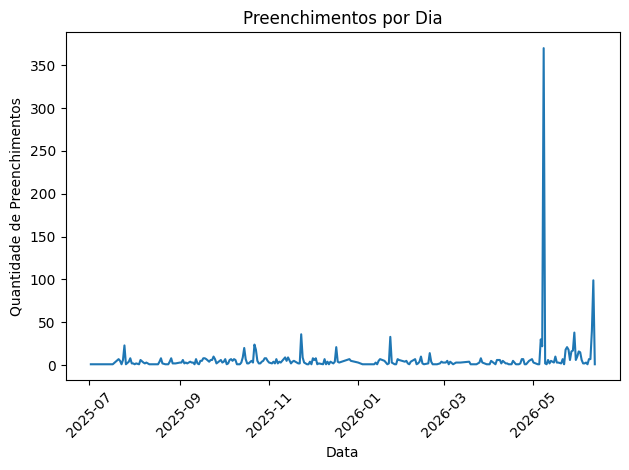

In [34]:
#Colocar o resultado em gráfico de linhas pelo nomeCalculadora


plt.plot(preenchimentos_por_dia['preenchimento_dt'], preenchimentos_por_dia['quantidade_preenchimentos'])
plt.xlabel('Data')
plt.ylabel('Quantidade de Preenchimentos')
plt.title('Preenchimentos por Dia')

plt.xticks(rotation=45)
plt.tight_layout()


plt.show()

In [35]:
#calcular o número de acessos por mês-ano
usuarios['mes_ano'] = usuarios['preenchimento_dt'].dt.to_period('M')
acessos_por_mes = usuarios.groupby('mes_ano').size().reset_index(name='quantidade_acessos')
print(acessos_por_mes)

    mes_ano  quantidade_acessos
0   2025-07                  61
1   2025-08                  57
2   2025-09                 120
3   2025-10                 180
4   2025-11                 137
5   2025-12                  89
6   2026-01                  81
7   2026-02                  75
8   2026-03                  43
9   2026-04                  79
10  2026-05                 626
11  2026-06                 199


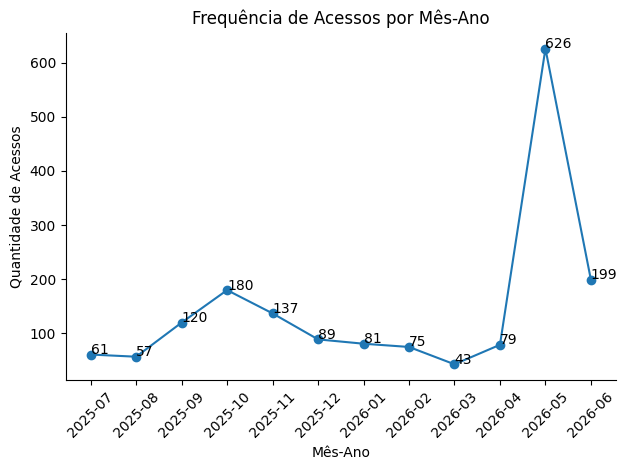

In [36]:
plt.plot(acessos_por_mes['mes_ano'].astype(str), acessos_por_mes['quantidade_acessos'], marker='o')
plt.xlabel('Mês-Ano')
plt.ylabel('Quantidade de Acessos')
plt.title('Frequência de Acessos por Mês-Ano')

#Retirar bordas
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Gráfico Flutuante
# ax.spines['bottom'].set_visible(False)
# ax.spines['left'].set_visible(False)

for i , v in enumerate(acessos_por_mes['quantidade_acessos']):
    plt.text(i, v + 1, str(v),  va = 'baseline')
plt.xticks(rotation=45)
plt.tight_layout()


plt.show()

In [37]:
# Quantificar quantos preenchimentos foram realizados por profissionais da saúde
profissional_saude = usuarios.groupby('profissionalSaude').size().reset_index(name='frequencia_utilizacao')
print(profissional_saude)

   profissionalSaude  frequencia_utilizacao
0              False                   1319
1               True                    428


In [38]:
#alterar a tag True/ False para Sim/ Não
profissional_saude['profissionalSaude'] = profissional_saude['profissionalSaude'].replace({True: 'Sim', False: 'Não'})
print(profissional_saude)

  profissionalSaude  frequencia_utilizacao
0               Não                   1319
1               Sim                    428


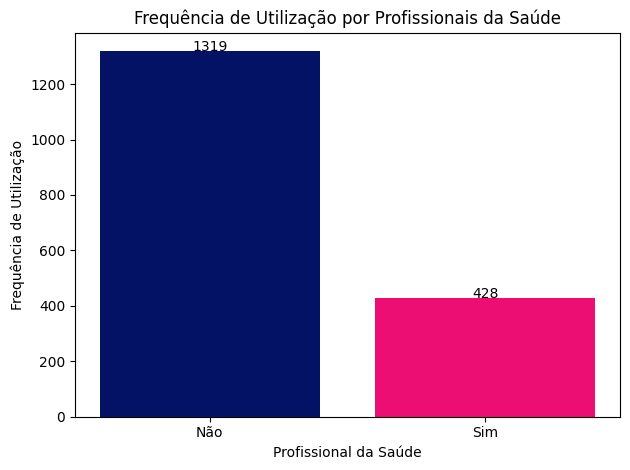

In [39]:
# representar em gráfico de barras
plt.bar(profissional_saude['profissionalSaude'], profissional_saude['frequencia_utilizacao'], color=['#041266', '#EC0E73'])
plt.xlabel('Profissional da Saúde')
plt.ylabel('Frequência de Utilização')
plt.title('Frequência de Utilização por Profissionais da Saúde')
plt.tight_layout()
# exibir rtótulo de dados
for i, v in enumerate(profissional_saude['frequencia_utilizacao']):
    plt.text(i, v + 1, str(v), ha='center')
plt.show()

In [40]:
# Quantificar os registros pelo tipo de calculadora preenchida, contabilizando também os valores nulos
tipo_calculadora = usuarios['nomeCalculadora'].value_counts(dropna=True).reset_index()
tipo_calculadora = tipo_calculadora.rename(columns={'index': 'nomeCalculadora', 'nomeCalculadora': 'Calculadora'})
print(tipo_calculadora)

        Calculadora  count
0     SCORE Caprini   1081
1              RCOG    370
2             Padua    175
3  Improve Bleeding    114
4         ImproveDD      7


In [41]:
# Calcular o número de preenchimento em nomeCalculadora, a partir da tabela resultado, calculando por valores únicos de user_id
calculadora = resultado.groupby('nomeCalculadora')['user_id'].nunique()
#renomear colunas
calculadora = calculadora.reset_index(name='frequencia')
calculadora = calculadora.rename(columns={'nomeCalculadora': 'calculadora'})
calculadora = calculadora.sort_values(['frequencia'], ascending=False)
calculadora

,calculadora,frequencia
4,SCORE Caprini,1081
3,RCOG,370
2,Padua,176
0,Improve Bleeding,114
1,ImproveDD,7


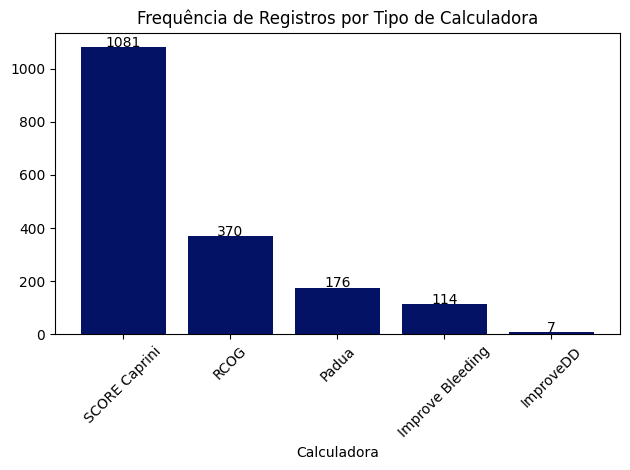

In [42]:
plt.bar(calculadora['calculadora'], calculadora['frequencia'], color = '#041266')
plt.xlabel('Calculadora')

plt.title('Frequência de Registros por Tipo de Calculadora')
plt.xticks(rotation=45)
for i, v in enumerate(calculadora['frequencia']):
    plt.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

In [43]:
status_preenchimento =usuarios['statusPreenchimento'].value_counts(dropna=False).reset_index()
status_preenchimento = status_preenchimento.rename(columns={'index': 'statusPreenchimento', 'statusPreenchimento': 'Status de Preenchimento'})
print(status_preenchimento)

  Status de Preenchimento  count
0              incompleto    950
1                completo    797


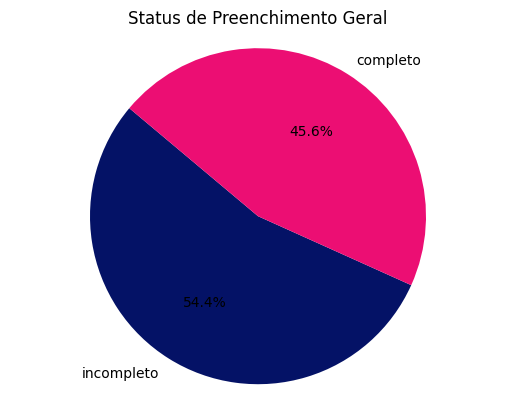

In [44]:
plt.pie(status_preenchimento['count'], labels=status_preenchimento['Status de Preenchimento'], autopct='%1.1f%%', startangle=140, colors=['#041266', '#EC0E73'])
plt.title('Status de Preenchimento Geral')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [45]:
# status de preenchimento estratificado por profissional da saúde
status_profissional = usuarios.groupby(['statusPreenchimento', 'profissionalSaude']).size().reset_index(name='frequencia')
status_profissional['profissionalSaude'] = status_profissional['profissionalSaude'].replace({True: 'Sim', False: 'Não'})
status_profissional

,statusPreenchimento,profissionalSaude,frequencia
0,completo,Não,444
1,completo,Sim,353
2,incompleto,Não,875
3,incompleto,Sim,75


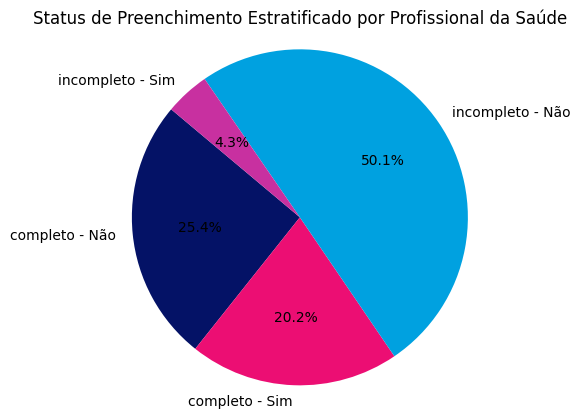

In [46]:
plt.pie(status_profissional['frequencia'], labels=status_profissional['statusPreenchimento'] + ' - ' + status_profissional['profissionalSaude'], autopct='%1.1f%%', startangle=140, colors=['#041266', '#EC0E73', '#00A1E0', '#C830A0'])
plt.title('Status de Preenchimento Estratificado por Profissional da Saúde')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

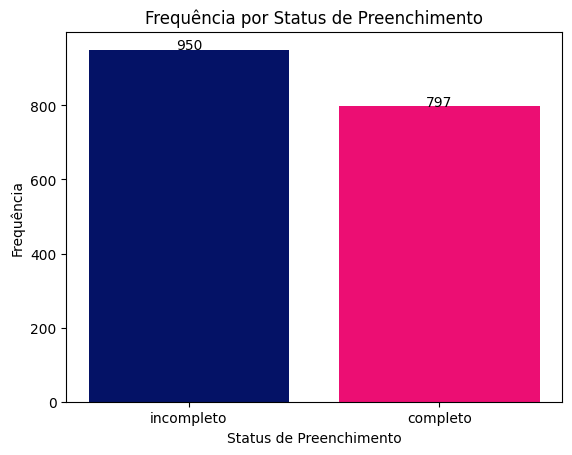

In [47]:
plt.bar(status_preenchimento['Status de Preenchimento'], status_preenchimento['count'], color=['#041266', '#EC0E73'])
plt.xlabel('Status de Preenchimento')
plt.ylabel('Frequência')
plt.title('Frequência por Status de Preenchimento')
for i, v in enumerate(status_preenchimento['count']):
    plt.text(i, v + 1, str(v), ha='center')
plt.show()

In [48]:
# Classificar da seguinte forma: NI = Não identificado, != NI: Identificado
usuarios['classificacao_usuario'] = np.where(
    usuarios['email'] == 'NI', 
    'Usuários não se identificou', 
    'Usuário se identificou'
)
identificacao = usuarios['classificacao_usuario'].value_counts()
print(identificacao)

classificacao_usuario
Usuários não se identificou    940
Usuário se identificou         807
Name: count, dtype: int64


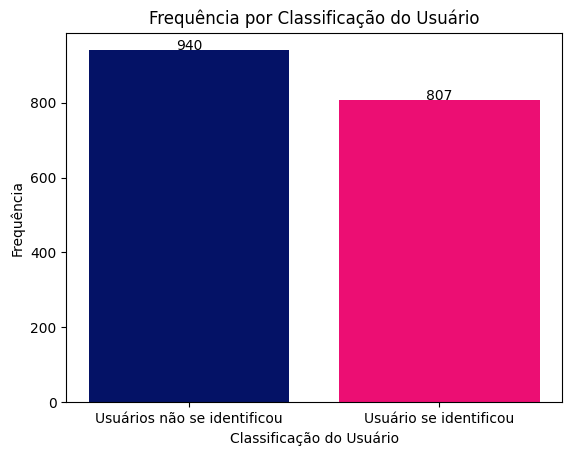

In [49]:
plt.bar(identificacao.index, identificacao.values, color=['#041266', '#EC0E73'])
plt.xlabel('Classificação do Usuário')
plt.ylabel('Frequência')
plt.title('Frequência por Classificação do Usuário')
for i, v in enumerate(identificacao.values):
    plt.text(i, v + 1, str(v), ha='center')
plt.show()